In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MLDATASETS/Customer_Segmentation_Project/Mall_Customers.csv')
print(df.head())

print('\n Info')
print(df.info())

print('\n Statistics')
print(df.describe(include = 'all'))

print('\n Missing Values Count per column')
print(df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

 Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

 Statistics
        CustomerID  Gender     

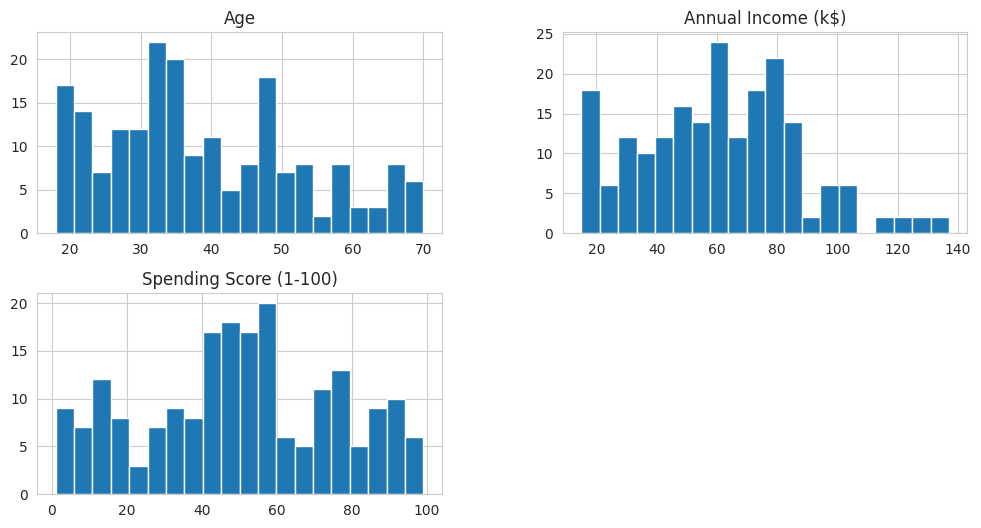

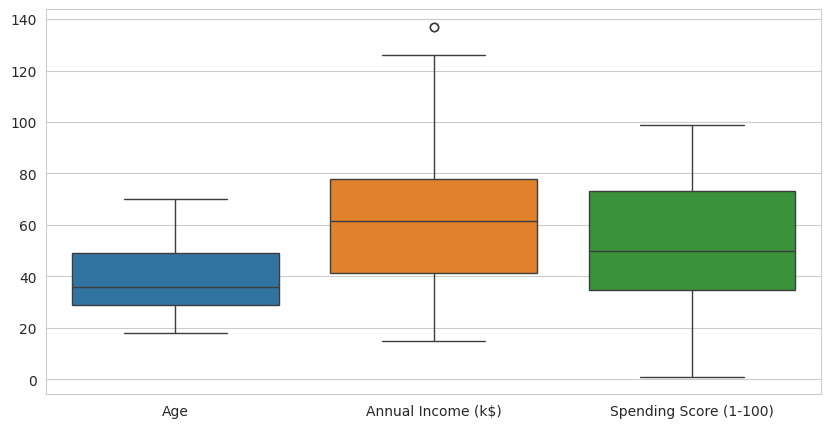

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Histograms for numerical columns
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(bins=20, figsize=(12, 6))
plt.show()

# Box plots to check outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

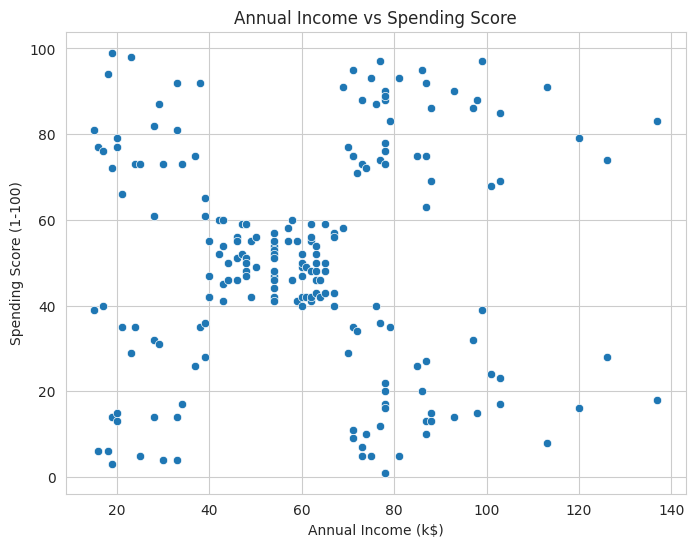

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

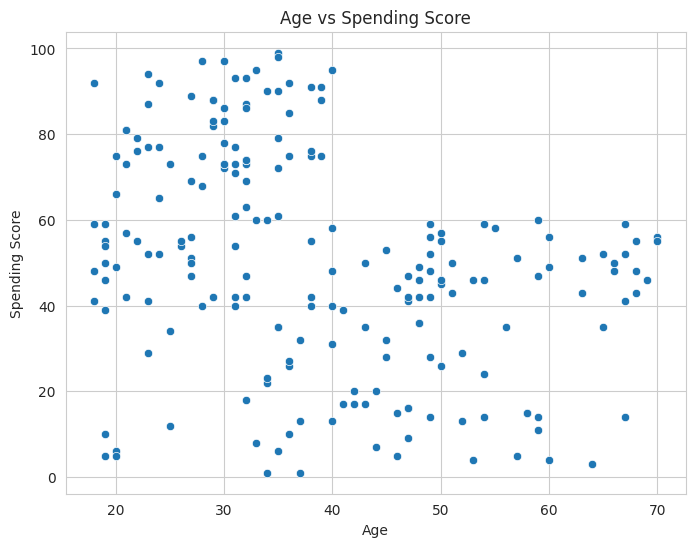

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)"
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()

In [8]:
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [9]:
numerical_features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

numerical_features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(numerical_features)
display(scaled_features[:5])

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

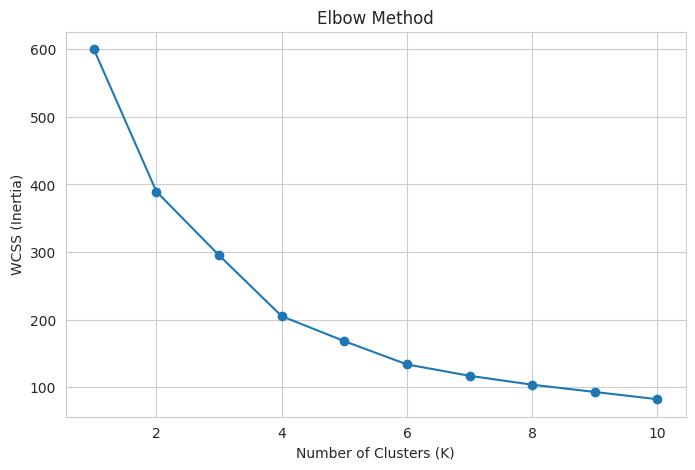

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.show()

In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):   # Silhouette Score K=1 ke liye define nahi hota

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3355
K = 3, Silhouette Score = 0.3578
K = 4, Silhouette Score = 0.4040
K = 5, Silhouette Score = 0.4166
K = 6, Silhouette Score = 0.4284
K = 7, Silhouette Score = 0.4172
K = 8, Silhouette Score = 0.4082
K = 9, Silhouette Score = 0.4177
K = 10, Silhouette Score = 0.4066


In [13]:
kmeans = KMeans(
    n_clusters=6,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

In [14]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,4
2,Female,20,16,6,5
3,Female,23,16,77,4
4,Female,31,17,40,5


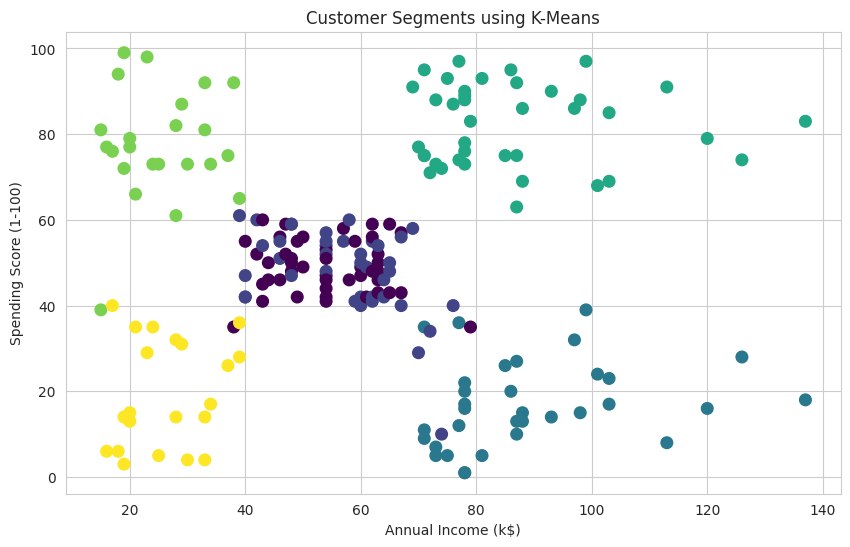

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.show()

In [16]:
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean() # To check the reason, of blue and purple center clusters, and we found the reason is that "age"

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


In [17]:
import plotly.express as px
fig = px.scatter_3d(
    df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    z="Age",
    color=df["Cluster"].astype(str),   # Har cluster ka alag color
    title="3D Customer Segmentation using K-Means",
    labels={
        "Annual Income (k$)": "Annual Income (k$)",
        "Spending Score (1-100)": "Spending Score",
        "Age": "Age",
        "color": "Cluster"
    }
)

fig.update_traces(marker=dict(size=5))

fig.show()

In [18]:
centroids = kmeans.cluster_centers_

print(centroids)

[[ 1.25472096 -0.24021294 -0.04399777]
 [-0.86515664 -0.13196835 -0.08043031]
 [ 0.22171558  1.08322527 -1.29005223]
 [-0.44191719  0.99158305  1.23950275]
 [-0.99396865 -1.34734766  1.06404834]
 [ 0.47895722 -1.30822992 -1.19644353]]


In [19]:
centroids_original = scaler.inverse_transform(centroids)

centroids_original

array([[56.33333333, 54.26666667, 49.06666667],
       [26.79487179, 57.1025641 , 48.12820513],
       [41.93939394, 88.93939394, 16.96969697],
       [32.69230769, 86.53846154, 82.12820513],
       [25.        , 25.26086957, 77.60869565],
       [45.52380952, 26.28571429, 19.38095238]])

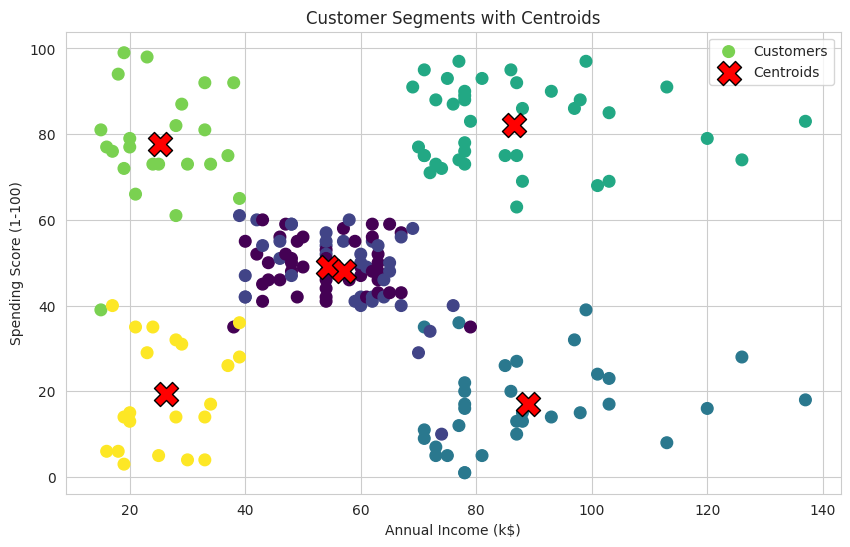

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Customers
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70,
    label="Customers"
)

# Centroids
plt.scatter(
    centroids_original[:,1],   # Income
    centroids_original[:,2],   # Spending
    c="red",
    s=300,
    marker="X",
    edgecolors="black",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments with Centroids")
plt.legend()

plt.show()

In [21]:
cluster_summary = df.groupby("Cluster").agg(
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean"),
    Number_of_Customers=("Cluster", "size")
)

cluster_summary

,Average_Age,Average_Income,Average_Spending,Number_of_Customers
Cluster,,,,
0,56.333333,54.266667,49.066667,45
1,26.794872,57.102564,48.128205,39
2,41.939394,88.939394,16.969697,33
3,32.692308,86.538462,82.128205,39
4,25.000000,25.260870,77.608696,23
5,45.523810,26.285714,19.380952,21


In [22]:
cluster_names = {
    0: "Mature Balanced Customers",
    1: "Young Moderate Customers",
    2: "Potential Customers",
    3: "Premium Customers",
    4: "Young High Spenders",
    5: "Budget Customers"
}
df["Customer Segment"] = df["Cluster"].map(cluster_names)
df.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,Male,19,15,39,4,Young High Spenders
1,Male,21,15,81,4,Young High Spenders
2,Female,20,16,6,5,Budget Customers
3,Female,23,16,77,4,Young High Spenders
4,Female,31,17,40,5,Budget Customers
5,Female,22,17,76,4,Young High Spenders
6,Female,35,18,6,5,Budget Customers
7,Female,23,18,94,4,Young High Spenders
8,Male,64,19,3,5,Budget Customers
9,Female,30,19,72,4,Young High Spenders


In [23]:
import joblib
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
import os

print(os.listdir())

['.config', 'scaler.pkl', 'kmeans_model.pkl', 'drive', 'sample_data']
